#### Load and Explore the Dataset
Objective: Load the dataset and examine its structure.
Tasks: Load the digits dataset from the sklearn.datasets library.


In [3]:
from sklearn.datasets import load_digits
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [4]:
# loading digits 
digits = load_digits()

Display the shape of X (feature data) and y (label data) to undestand the dataset's dimesons

In [6]:
# first, assign X and y as dictated
X, y = digits.data, digits.target

In [9]:
# print the shapes of these new variables
print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)

Shape of X (features): (1797, 64)
Shape of y (labels): (1797,)


Randomly split the dataset into training and test sets, reserve 500 samples for the test set

In [12]:
# test train split, with a size of 400
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=500, random_state=42)

Display the shapes rendered by splitting

In [15]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("\nShape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1297, 64)
Shape of y_train: (1297,)

Shape of X_test: (500, 64)
Shape of y_test: (500,)


Select 10 random images from X_train and the matching labels from y_train

Display these images in a grid using matplotlib, each image and label corresponds.

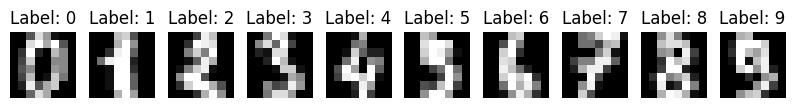

In [19]:
# creating the visualization using a for loop where i is the iteration per image
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(1, 10, i + 1) # one rows, 10 images, iterate i+1 
    plt.imshow(digits.images[i], cmap='gray') # image = i, grayscale
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.show()

Train 5 seperate k-NN classifiers to predict digit labels where k = 1, 3, 5, 7, 9

For each classifier, fit the model using X_train and y_train

In [24]:
k = [1,3,5,7,9] # set values for k
classifiers = {} # skeleton for the dictionary holding my classifications

for k in k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    classifiers[k] = knn
    #print("Classifier Result for iteration k =", k)

Predict the labels of X_test and calculate the F1 score using y_test. Then summarize the results in a dataframe and markdown cell

In [29]:
scores = {} # to hold f1 scores

# make scores in a loop, iterate over k values and save them
for k, classifier in classifiers.items():
    y_prediction = classifier.predict(X_test)  # Use classifier instead of knn
    f1_score_value = f1_score(y_test, y_prediction, average="weighted")
    scores[k] = f1_score_value

In [34]:
# create a df to display the scores held in "scores"
f1_scores_df = pd.DataFrame(list(scores.items()), columns=['k', 'F1 Score'])
f1_scores_df.sort_values(by='k', inplace=True)
f1_scores_df.reset_index(drop=True, inplace=True)

f1_scores_df

,k,F1 Score
0,1,0.984033
1,3,0.989941
2,5,0.993981
3,7,0.991967
4,9,0.981890


From the scores calculated, the highest F1 score is when k=5. This would suggest that out of all possible trials, the most efficient one to hold would be where k is equal to 5. Taking this into account, all F1 scores are relatively close. Choosing the highest F1 score ensures the testing data is the least problematic (underfitting/overfitting risks). Out of all k values, even though they are relatively close, k = 5 is the closest to 1.

Select items from each classifier (k = n) to display using X_test for images.

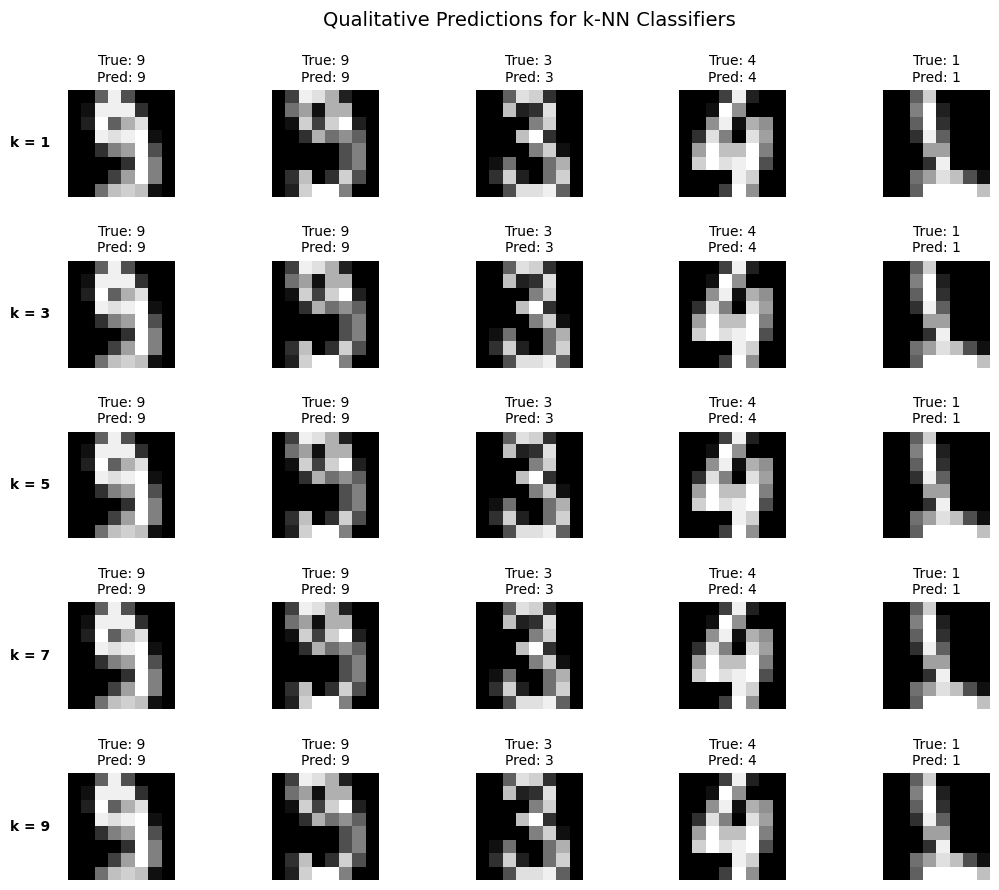

In [51]:
# pick random images through index
choices = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12, 10))
# display each prediction/classification row using index loops
for idx, (k, classifier) in enumerate(classifiers.items()):
    for i, sample_idx in enumerate(choices):
        # display images and labels (true and predictions)
        sample_image = X_test[sample_idx].reshape(8, 8)
        true_label = y_test[sample_idx]
        predicted_label = classifier.predict([X_test[sample_idx]])[0]
        # create the visualization through subplots, iterating over each index choice
        plt.subplot(len(classifiers), 5, idx * 5 + i + 1)
        plt.imshow(sample_image, cmap='gray')
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
    plt.text(-7.8, 0.5, f"k = {k}", va='center', ha='right', fontsize=10, fontweight = 'bold', 
             transform=plt.gca().transAxes)

plt.suptitle("Qualitative Predictions for k-NN Classifiers", fontsize=14)
plt.subplots_adjust(left=0.1, top=0.9, wspace=0.4, hspace=0.6)
plt.show()